Ścieżki Pythona (ostatnie 5): ['C:\\Users\\elbob\\miniconda3\\Lib\\site-packages\\win32', 'C:\\Users\\elbob\\miniconda3\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\elbob\\miniconda3\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\elbob\\miniconda3\\Lib\\site-packages\\setuptools\\_vendor', 'C:\\Users\\elbob\\Desktop\\wm_model\\neuronaldynamics-exercises']
Plik requirements.txt: C:\Users\elbob\Desktop\wm_model\neuronaldynamics-exercises\requirements.txt -> True
  Using cached numpy-1.26.4-cp313-cp313-win_amd64.whl
  Using cached scipy-1.12.0.tar.gz (56.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Moduły zaimportowane


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [44 lines of output]
  + meson setup C:\Users\elbob\AppData\Local\Temp\pip-install-srjxm5od\scipy_f922d0a6547e4dc4aab28951fe430936 C:\Users\elbob\AppData\Local\Temp\pip-install-srjxm5od\scipy_f922d0a6547e4dc4aab28951fe430936\.mesonpy-o19x0zf2 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\elbob\AppData\Local\Temp\pip-install-srjxm5od\scipy_f922d0a6547e4dc4aab28951fe430936\.mesonpy-o19x0zf2\meson-python-native-file.ini
  The Meson build system
  Version: 1.10.0
  Source dir: C:\Users\elbob\AppData\Local\Temp\pip-install-srjxm5od\scipy_f922d0a6547e4dc4aab28951fe430936
  Build dir: C:\Users\elbob\AppData\Local\Temp\pip-install-srjxm5od\scipy_f922d0a6547e4dc4aab28951fe430936\.mesonpy-o19x0zf2
  Build type: native build
  Project name: scipy
  Project version: 1.12.0
  C compiler for the host machine: C:\Nowy folder\winlibs-x86_64-posix-

(<Figure size 1000x400 with 3 Axes>,
 <Axes: title={'center': 'Raster Plot'}, ylabel='neuron #'>,
 <Axes: title={'center': 'Population Activity'}, ylabel='A(t) [Hz]'>,
 <Axes: title={'center': 'Voltage Traces'}, xlabel='t [ms]', ylabel='V(t) [mV]'>)

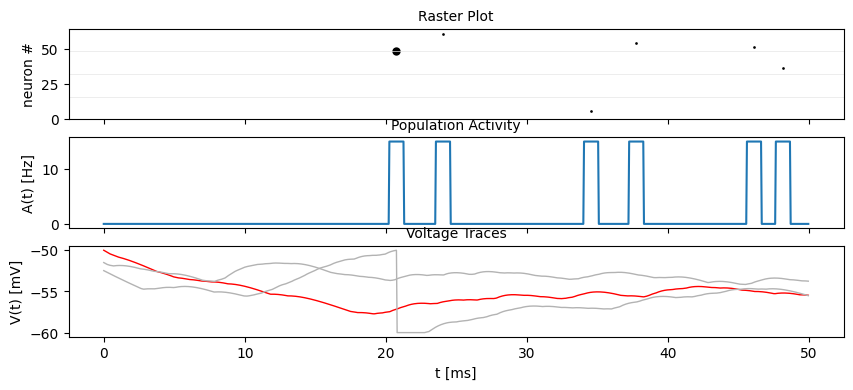

In [5]:
# =========================================
# 1.Ustawienie ścieżek do repozytorium
# =========================================
import sys
import os

# Ścieżka do katalogu neuronaldynamics-exercises
repo_path = os.path.abspath("../../")  # cofa się dwa poziomy z working_memory_network
if repo_path not in sys.path:
    sys.path.append(repo_path)

print("Ścieżki Pythona (ostatnie 5):", sys.path[-5:])

# =========================================
# 2.Instalacja pakietów (jeśli jeszcze nie zainstalowane)
# =========================================
req_file = os.path.join(repo_path, "requirements.txt")
print("Plik requirements.txt:", req_file, "->", os.path.isfile(req_file))

import sys
!{sys.executable} -m pip install -r "{req_file}"

# =========================================
# 3️.Import modułów
# =========================================
import brian2 as b2
b2.prefs.codegen.target = 'numpy'  # wymuszenie trybu numpy (bez Visual C++)

import wm_model
from neurodynex3.tools import plot_tools as pt

print("Moduły zaimportowane")

# =========================================
# 4️.Szybka testowa symulacja małej sieci
# =========================================
rate_ex, spike_ex, volt_ex, idx_ex, \
rate_in, spike_in, volt_in, idx_in, \
weights = wm_model.simulate_wm(
    N_excitatory=64,    # mała sieć testowa
    N_inhibitory=16,
    sim_time=50*b2.ms   # krótszy czas symulacji
)

# =========================================
# 5️.Wykres aktywności
# =========================================
pt.plot_network_activity(rate_ex, spike_ex, volt_ex)